In [2]:
#testing LLM

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm
import matplotlib.pyplot as plt

# 1. Data Generation and Manipulation

In [5]:
#build dataset
n = 500

dog_id = np.arange(10001, 10001 + n)

name = np.random.choice(["Fluffy","Brutus","Henry","Sina"], size=n)

age = skewnorm.rvs(5, loc=3, scale=4, size=n)
age = np.clip(age, 0, 20).astype(int)

walks_today = np.random.poisson(2, n).astype(float)
#trap: some are decimals, need to be integers logically
# choose indices to corrupt
idx = np.random.choice(n, 25, replace=False)
# add decimal part (.x)
walks_today[idx] += np.random.randint(1, 10, size=25) / 10

# is the dog fed?
fed = np.random.choice([1,0],p=[0.8,0.2],size=n)

# cookie type?
cookie_type = np.random.choice(["chocolate_chips","butter","shortbread","vanilla"],size=n)

# was the cookie eaten?
cookie_score = (
    0.08 * (walks_today - 2)
    - 0.12 * age
    - 0.8 * fed
)
p = 1 / (1 + np.exp(-cookie_score))
cookie_eaten = np.random.binomial(1, p)

# create df
df = pd.DataFrame({
    "dog_id": dog_id,
    "name": name,
    "age": age,
    "walks_today": walks_today,
    "fed": fed,
    "cookie_type": cookie_type,
    "cookie_eaten": cookie_eaten
})

# manipulate df
## remove entries
missing_idx = np.random.choice(df.index, 25, replace=False)
df.loc[missing_idx[:10], "age"] = np.nan
df.loc[missing_idx[10:20], "fed"] = np.nan
df.loc[missing_idx[20:], "cookie_type"] = np.nan

## inject category variations
category_idx = np.random.choice(df.index, 20, replace=False)
df.loc[category_idx[:5], "name"] = "fluffy"
df.loc[category_idx[5:10], "name"] = "FLUFFY"
df.loc[category_idx[10:], "cookie_type"] = "chocolate-chips"

## inject outliers
outlier_idx = np.random.choice(df.index, 7, replace=False)
df.loc[outlier_idx[:4], "age"] = [30,55,28,45]
df.loc[outlier_idx[4:], "walks_today"] = [100,120,55]

## inject illogical negative data
negative_idx = np.random.choice(df.index, 2, replace=False)
df.loc[negative_idx[0], "age"] = -np.abs(df.loc[negative_idx[0], "age"])
df.loc[negative_idx[1], "walks_today"] = -np.abs(df.loc[negative_idx[1], "walks_today"])

##duplicate some rows
dup_rows = df.sample(5, random_state=123).copy()

start_id = df["dog_id"].max() + 1
dup_rows["dog_id"] = np.arange(start_id, start_id + len(dup_rows))

df = pd.concat([df, dup_rows], ignore_index=True)

# 2. Explanation of Injected Data Issues

This dataset intentionally includes several data quality issues to evaluate whether a model can perform robust exploratory data analysis beyond surface-level statistics.

## 1. Inconsistent categorical labels
The name column contains variations such as:
"Fluffy", "fluffy", "FLUFFY"
The cookie_type column includes:
"chocolate_chips" and "chocolate-chips"

**Purpose:**
Tests whether the model detects and accounts for inconsistent category representations before performing grouped analysis.

## 2. Invalid data types (discrete → continuous contamination)
walks_today represents a count variable (number of walks), but some values include decimals (e.g. 2.3, 1.7)

**Purpose:**
Tests whether the model recognises that the variable should be discrete and flags non-integer values as potential data issues.

## 3. Missing values
Missing values are introduced in:
age
fed
cookie_type

**Purpose:**
Evaluates whether the model identifies missing data and considers its potential impact on analysis.

## 4. Outliers
Implausible values are inserted:
age: e.g. 30, 45, 55 (unrealistic for dogs)
walks_today: e.g. 55, 100, 120

**Purpose:**
Tests whether the model detects extreme values and accounts for their influence on summary statistics.

## 5. Logically invalid values
Negative values are introduced:
negative age
negative walks_today

**Purpose:**
Assesses whether the model recognises violations of domain constraints (e.g. age cannot be negative).

## 6. Duplicate records with different identifiers
Some rows are duplicated but assigned new dog_id values

**Purpose:**
Tests whether the model can detect duplicated observations that are not trivially identical due to differing identifiers.

## Overall goal

These issues are designed to require:

data cleaning awareness,
semantic reasoning about variables,
cautious interpretation of results

rather than relying on straightforward statistical summaries.



# 3. Target Generation

The target variable cookie_eaten is generated using a probabilistic model based on a latent score.

## 1. Cookie score (linear combination)

A continuous score is computed from selected features:

cookie_score = (
    0.08 * (walks_today - 2)
    - 0.12 * age
    - 0.8 * fed
)

**Interpretation:**

More walks → slightly higher likelihood of eating a cookie

Higher age → lower likelihood

Being fed (fed = 1) → significantly lower likelihood

This score represents an underlying tendency rather than a direct probability.

## 2. Mapping score to probability (sigmoid function)

The score is transformed into a probability using the sigmoid function:

p = 1 / (1 + np.exp(-cookie_score))

**Properties:**

Maps any real-valued score to a range between 0 and 1
Values near 0 → probability ≈ 0.5
Large positive values → probability → 1
Large negative values → probability → 0

This ensures the output can be interpreted as a valid probability.

## 3. Sampling the binary outcome (stochastic step)

The final target is generated by sampling from a Bernoulli distribution:

cookie_eaten = np.random.binomial(1, p)

**Interpretation:**

Each observation has probability p of being 1.
The outcome is stochastic (not deterministic)

## Rationale

This approach introduces:

structured signal (via cookie_score)
realistic variability (via stochastic sampling)

As a result, the relationship between features and target is:

detectable, but
non-trivial, requiring careful analysis rather than simple rules

# 4. Validation & Sanity Checks

To ensure the dataset behaves as intended, several checks are performed.

## 1. Distribution of probabilities

Purpose:

Verify probabilities are not collapsed around 0.5
Ensure a meaningful spread (signal present but not extreme)

mean =  0.22
min =  0.06
max =  0.51
std =  0.08


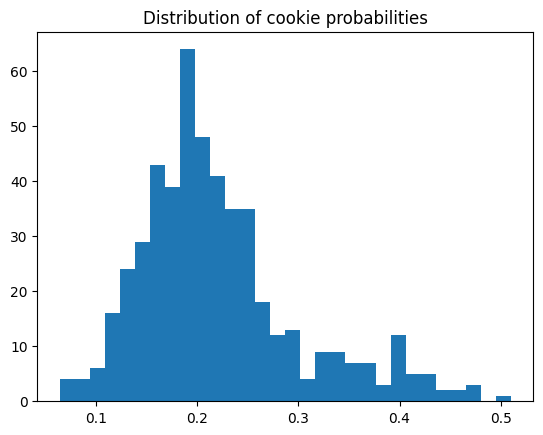

In [9]:
print("mean = ", round(p.mean(),2))
print("min = ", round(p.min(),2))
print("max = ", round(p.max(),2))
print("std = ", round(p.std(),2))
plt.hist(p, bins=30)
plt.title("Distribution of cookie probabilities");

# 2. Outcome balance
Purpose:

Check class balance
Avoid degenerate cases (e.g. all 0s or all 1s)

In [12]:
df["cookie_eaten"].value_counts(normalize=True)

cookie_eaten
0    0.774257
1    0.225743
Name: proportion, dtype: float64

## 3. Relationship between features and target

Purpose:

Confirm that key features influence the target in expected directions
Ensure the signal is detectable through simple aggregation

In [13]:
df.groupby("fed")["cookie_eaten"].mean()
df.groupby("walks_today")["cookie_eaten"].mean()

walks_today
-1.0      0.000000
 0.0      0.145161
 0.1      0.000000
 0.5      0.000000
 1.0      0.185484
 1.1      0.000000
 1.8      0.500000
 2.0      0.228346
 2.2      0.000000
 2.3      0.000000
 2.4      0.000000
 2.7      1.000000
 3.0      0.270000
 3.1      0.000000
 3.2      0.000000
 3.4      1.000000
 3.5      0.000000
 3.6      0.000000
 3.8      1.000000
 3.9      0.000000
 4.0      0.243902
 4.8      1.000000
 4.9      1.000000
 5.0      0.333333
 5.5      0.000000
 5.6      1.000000
 6.0      0.500000
 6.1      0.000000
 6.4      1.000000
 7.0      0.000000
 55.0     0.000000
 100.0    0.000000
 120.0    0.000000
Name: cookie_eaten, dtype: float64

## 4. Correlation analysis
Purpose:

Identify which variables are associated with the target.
Verify that the constructed signal is reflected in the data

In [16]:
df.corr(numeric_only=True)["cookie_eaten"].sort_values(ascending=False)

cookie_eaten    1.000000
dog_id          0.028202
walks_today    -0.011936
age            -0.051582
fed            -0.162713
Name: cookie_eaten, dtype: float64

## Summary

These checks confirm that:

the dataset contains meaningful but noisy signal
relationships are recoverable but not trivial
data issues (missing values, inconsistencies, outliers) coexist with the signal

This makes the dataset suitable for evaluating robust exploratory data analysis by LLMs.